## **Estimating Total Factor Productivity**

## **1. Setup**

In [1]:
import pandas as pd
import numpy as np
import sys
from pathlib import Path
import matplotlib.pyplot as plt
from statsmodels.iolib.summary2 import summary_col
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.formula.api import ols
from sklearn.preprocessing import PolynomialFeatures
from scipy.optimize import minimize_scalar, minimize
import seaborn as sns

parent_dir = Path.cwd().parent
sys.path.append(f'{parent_dir}/py_modules')

from capital_est_modules import reset_diff_on_drop, capital_measures, fixed_effects_model, decomposition, TFP_plot
import OP_model
import ACF_model
import ACF_full as acf

## **2. Load Data**

In [2]:
financial_data = pd.read_excel(f'{parent_dir}/data/Annual Financial Data.xlsx')

### **2.1. Set up variables and data**

#### **Time variables and value added**

In [3]:
unique_years = sorted(list(financial_data['Data Year - Fiscal'].unique()))
year_categories = range(1, len(unique_years) + 1)

mapping_dict = dict(zip(unique_years, year_categories))
financial_data = financial_data.copy()
financial_data['time'] = financial_data['Data Year - Fiscal'].map(mapping_dict)

time_col = financial_data.pop('time')
financial_data.insert(2, 'time', time_col)

In [4]:
financial_data['Value Added'] = financial_data['Revenue - Total'] - financial_data['Cost of Goods Sold']

#### **Survival variable for the Olley-Pakes model**

In [5]:
MAX_TIME = financial_data['time'].max()                                                                                                                                         
                                                                                                                                                                                
def flag_exit(df):                                                                                                                                                              
    df = df.sort_values('time').copy()
    df['Survival'] = 1
    if df['time'].iloc[-1] != MAX_TIME:                                                                                                                                         
        df.iloc[-1, df.columns.get_loc('Survival')] = 0
    return df                                                                                                                                                                   
                                                                                                                                                                                
financial_data['Ticker Symbol 1'] = financial_data['Ticker Symbol']
financial_data = (financial_data
                .groupby('Ticker Symbol 1', group_keys=False)                                                                                                                   
                .apply(flag_exit))

#### **Model-Agnostic Variables & Clean-Up**

In [6]:
# Set Up Production Function Variables
identifiers = ['Ticker Symbol',
               'Data Year - Fiscal',
               'time', 
               'Date']

output = ['Revenue - Total', 'Value Added']

physical_capital = ['Property, Plant and Equipment - Total (Gross)',
                    'Inventories - Total',
                    'Working Capital (Balance Sheet)']

non_physical_capital = ['Intangible Assets - Total']

depreciation_cols = ['Depreciation, Depletion and Amortization (Accumulated)',
                     'Depreciation and Amortization']

labor = ['Employees']

additional_input_variable = ['Inventories - Raw Materials', 'Cost of Goods Sold']

survival = ['Survival']

cols = identifiers + output + physical_capital + non_physical_capital + depreciation_cols + labor + additional_input_variable + survival

financial_data = financial_data[cols]

financial_data['Physical Capital'] = financial_data[physical_capital].sum(axis=1)
financial_data['Non-Physical Capital'] = financial_data[non_physical_capital].sum(axis=1)
financial_data['PC & NPC'] = financial_data['Physical Capital'] + financial_data['Non-Physical Capital']

In [7]:
financial_data = financial_data.rename(columns={'Employees': 'Total Employment',
                                                'Data Year - Fiscal': 'year'})

financial_data = financial_data[financial_data['Total Employment'].notna()]
financial_data = financial_data[financial_data['Depreciation, Depletion and Amortization (Accumulated)'].notna()]
financial_data['Ticker Symbol'].astype(str)

financial_data['Depreciation, Depletion and Amortization (Accumulated)'] = pd.to_numeric(
        financial_data['Depreciation, Depletion and Amortization (Accumulated)'], errors='coerce')


In [8]:
missing_values = pd.DataFrame(financial_data.isna().sum())

missing_values.rename(columns={0: 'Missing Values'}, inplace=True)
missing_values[missing_values != 0].dropna()

,Missing Values
Revenue - Total,5.0
Value Added,5.0
Inventories - Total,37.0
Working Capital (Balance Sheet),9.0
Intangible Assets - Total,58.0
Depreciation and Amortization,5.0
Inventories - Raw Materials,653.0
Cost of Goods Sold,5.0


In [9]:
financial_data = financial_data.dropna()

In [10]:
financial_data = financial_data[(financial_data['Revenue - Total'] > 0)
                                & (financial_data['Value Added'] > 0)
                                & (financial_data['Cost of Goods Sold'] > 0)
                                & (financial_data['PC & NPC'] > 0)
                                & (financial_data['Total Employment'] > 0)
                                & (financial_data['time'].notna())]

In [11]:
symbols = list(financial_data['Ticker Symbol'].unique())

dfs = {}
for symbol in symbols:
    dfs[symbol] = financial_data[financial_data['Ticker Symbol'] == symbol].copy()

#### **Calculate Lagged Investment & Capital**

In [12]:
target_col = 'Depreciation, Depletion and Amortization (Accumulated)'

for symbol, df in dfs.items():
    # Find the index of the first non-NaN value in the target column
    first_valid_index = df[target_col].first_valid_index()

    # If a valid index exists, trim the DataFrame starting from that row
    if first_valid_index is not None:
        dfs[symbol] = df.loc[first_valid_index:].reset_index(drop=True)

In [13]:
capital_measures(dfs, 'PC & NPC', 1, 0)
capital_measures(dfs, 'PC & NPC', 2, 3)

In [14]:
financial_data = pd.DataFrame()

for df in dfs.values():
    financial_data = pd.concat([financial_data, df])

In [15]:
capital1 = financial_data
capital2 = financial_data[financial_data['Capital Measure 2'] > 0]

#### **Log-Transformation**

In [16]:
capital1 = capital1.copy()
capital2 = capital2.copy()

cols_to_log = ['Revenue - Total',
               'Cost of Goods Sold',
               'Total Employment',
               'Capital Measure 1',
               'Capital Measure 2',
               'Capital Expenditure',
               'Inventories - Raw Materials',
               'Value Added']

capital1 = capital1[(capital1[cols_to_log] > 0).all(axis=1)]
capital2 = capital2[(capital2[cols_to_log] > 0).all(axis=1)]

for col in cols_to_log:
    try:
        capital1[col] = np.log(capital1[col])
        capital2[col] = np.log(capital2[col])
    except:
        continue

### **2.2. Summary Statistics**

In [17]:
summary_cols = ['Revenue - Total', 
                'Value Added', 
                'Total Employment', 
                'Capital Measure 1']

capital1[summary_cols].agg(['count', 'median', 'std', 'min', 'max']).T

,count,median,std,min,max
Revenue - Total,2330.0,6.452593,2.328155,-1.096614,12.409511
Value Added,2330.0,5.586221,2.373448,-1.777857,12.160071
Total Employment,2330.0,0.746685,2.152389,-4.710531,5.548769
Capital Measure 1,2330.0,6.819803,2.374775,-0.787458,13.061443


In [18]:
summary_cols[-1] = 'Capital Measure 2'

capital2[summary_cols].agg(['count', 'median', 'std', 'min', 'max']).T

,count,median,std,min,max
Revenue - Total,2330.0,6.452593,2.328155,-1.096614,12.409511
Value Added,2330.0,5.586221,2.373448,-1.777857,12.160071
Total Employment,2330.0,0.746685,2.152389,-4.710531,5.548769
Capital Measure 2,2330.0,6.716972,2.356316,-0.791863,12.727684


## **Model 1: Simple Linear Regression**

In [19]:
capital1['const'] = 1
capital2['const'] = 1

capital1 = capital1.copy()
capital2 = capital2.copy()

variables_to_include_ols1 = capital1[['const',
                                      'Total Employment', 
                                      'Capital Measure 1']]
variables_to_include_ols2 = capital2[['const',
                                      'Total Employment',
                                      'Capital Measure 2']]

ols1 = sm.OLS(capital1['Value Added'], variables_to_include_ols1, missing='drop').fit()
ols2 = sm.OLS(capital2['Value Added'], variables_to_include_ols2, missing='drop').fit()

In [20]:
info_dict = {'F-stat': lambda x: f"{x.fvalue:.2f}",
             'F p-value': lambda x: f"{x.f_pvalue:.3f}",
             'N Obs': lambda x: f"{int(x.nobs)}",
             'SSR': lambda x: f"{x.ssr:.2f}",
             'ESS': lambda x: f"{x.ess:.2f}",
             'MSE Res': lambda x: f"{x.mse_resid:.2f}"}

ols_results_table = summary_col(results=[ols1, ols2],
                                float_format='%0.2f',
                                stars = True,
                                model_names=['Model 1', 'Model 2'],
                                info_dict=info_dict,
                                regressor_order=['const', 
                                                 'Capital Measure 1',
                                                 'Capital Measure 2',
                                                 'Total Employment'])

ols_results_table.add_title('Table: OLS Regressions')

print(ols_results_table)

      Table: OLS Regressions
                  Model 1  Model 2 
-----------------------------------
const             -0.23**  -0.05   
                  (0.10)   (0.10)  
Capital Measure 1 0.83***          
                  (0.02)           
Capital Measure 2          0.81*** 
                           (0.02)  
Total Employment  0.15***  0.18*** 
                  (0.02)   (0.02)  
R-squared         0.93     0.92    
R-squared Adj.    0.93     0.92    
ESS               12188.66 12130.20
F p-value         0.000    0.000   
F-stat            15229.48 14261.05
MSE Res           0.40     0.43    
N Obs             2330     2330    
SSR               931.19   989.65  
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


In [21]:
intercept_reg1 = ols1.params['const']
beta_employment_reg1 = ols1.params['Total Employment']
beta_capital1_reg1 = ols1.params['Capital Measure 1']

intercept_reg2 = ols2.params['const']
beta_employment_reg2 = ols2.params['Total Employment']
beta_capital2_reg2 = ols2.params['Capital Measure 2']

In [22]:
financial_data['MPK 2'] = beta_capital2_reg2 * (financial_data['Value Added'] / financial_data['Capital Measure 2'])
financial_data['MPN 2'] = beta_employment_reg2 * (financial_data['Value Added'] / financial_data['Total Employment']) 

In [23]:
MPK_df = financial_data[financial_data['Capital Measure 2'] != financial_data['Capital Measure 2'].min()]

In [24]:
MPK_df[['MPK 2', 'MPN 2']].describe()

,MPK 2,MPN 2
count,6013.000000,6013.000000
mean,0.560826,31.066723
std,7.769535,27.713449
min,0.000302,0.022981
25%,0.180670,13.447112
50%,0.286597,25.087474
75%,0.448305,40.355571
max,437.304367,500.166328


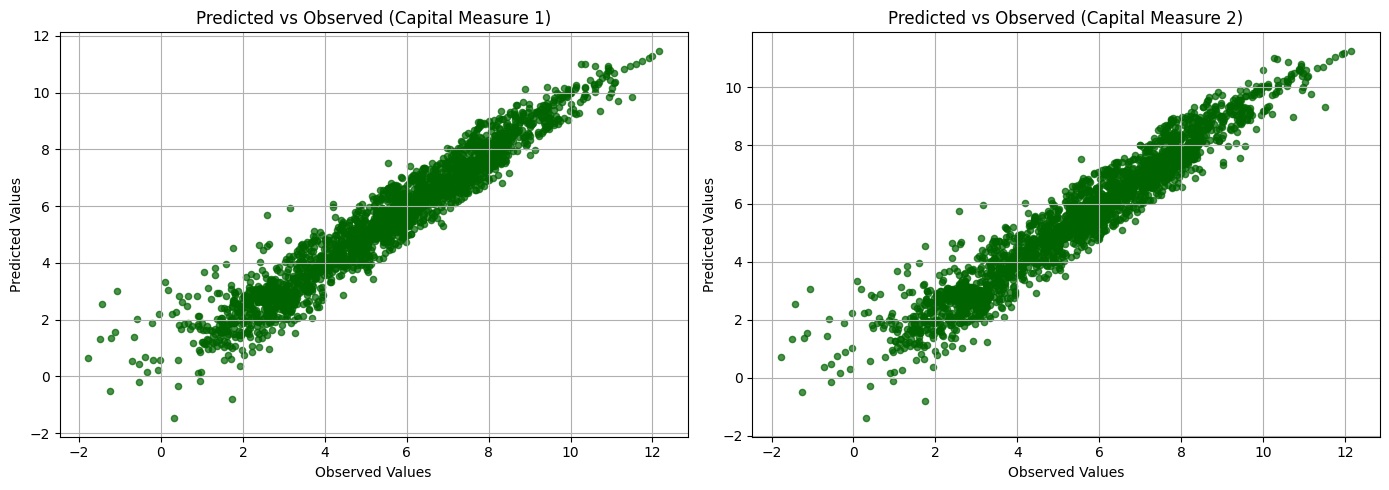

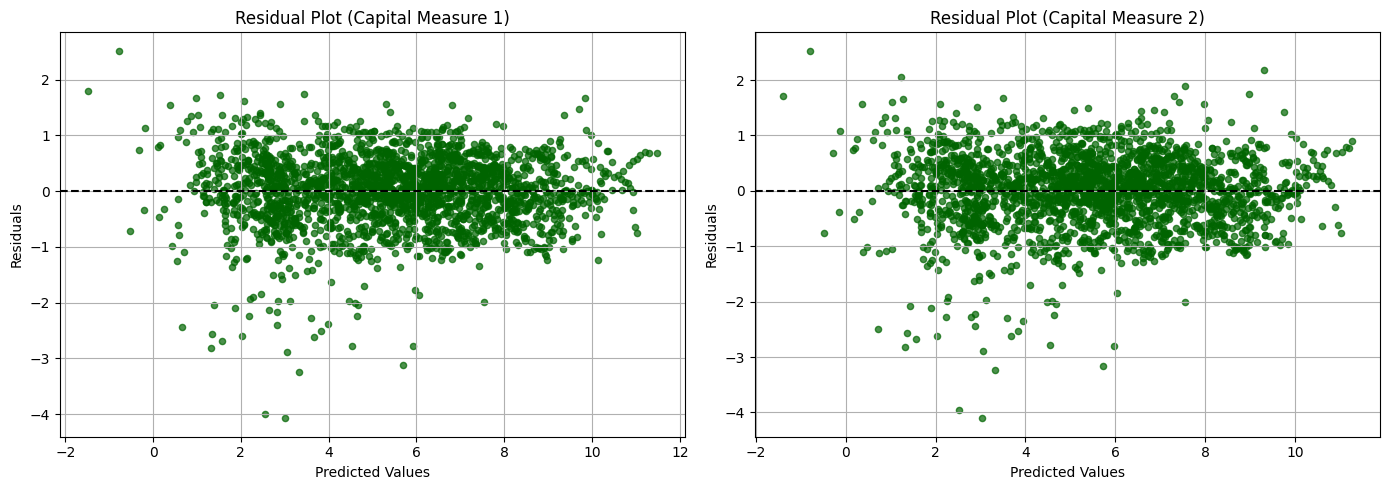

In [25]:
y_actual1 = capital1['Value Added']
y_actual2 = capital2['Value Added']

pred1 = ols1.predict(variables_to_include_ols1)
pred2 = ols2.predict(variables_to_include_ols2)

actuals_preds = [(capital1['Value Added'], pred1, 'Capital Measure 1'),
                 (capital2['Value Added'], pred2, 'Capital Measure 2')]

# Predicted vs Observed
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (y_actual, y_pred, label) in zip(axes, actuals_preds):
    ax.scatter(y_actual, y_pred, alpha=0.7, s=20, color='darkgreen')
    ax.set_title(f"Predicted vs Observed ({label})")
    ax.set_xlabel("Observed Values")
    ax.set_ylabel("Predicted Values")
    ax.grid(True)

plt.tight_layout()
plt.show()

# Residual Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (y_actual, y_pred, label) in zip(axes, actuals_preds):
    residuals = y_actual - y_pred
    ax.scatter(y_pred, residuals, alpha=0.7, s=20, color='darkgreen')
    ax.axhline(y=0, color='black', linestyle='--')
    ax.set_title(f"Residual Plot ({label})")
    ax.set_xlabel("Predicted Values")
    ax.set_ylabel("Residuals")
    ax.grid(True)

plt.tight_layout()
plt.show()

#### **Testing for Heteroscedasticity**

In [26]:
white_test = het_white(ols2.resid,  ols2.model.exog)
bp_test = het_breuschpagan(ols2.resid, ols2.model.exog)


In [27]:
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
bp_test = dict(zip(labels, bp_test))
white_test = dict(zip(labels, white_test))

test = pd.DataFrame([bp_test, white_test], index=['BP Test', 'White Test'])
test[['LM Statistic', 'LM-Test p-value']]

,LM Statistic,LM-Test p-value
BP Test,47.327344,5.284427e-11
White Test,190.620231,2.878935e-39


LM-Test p-value indicates that there is heteroscedasticity.

#### **Identifying Heterogeneity**

In [28]:
data = financial_data.dropna()

In [29]:
unit = 'Ticker Symbol'
outcome = 'Value Added'

group_means = data.groupby(unit)[outcome].mean()
overall_mean = data[outcome].mean()

between_var = ((group_means - overall_mean) ** 2 * data.groupby(unit).size()).sum()
within_var = data.groupby(unit).apply(
    lambda group: ((group[outcome] - group[outcome].mean()) ** 2).sum()).sum()
total_var = ((data[outcome] - overall_mean) ** 2).sum()

print(f"Between-unit variation: {between_var / total_var:.2%}")
print(f"Within-unit variation: {within_var / total_var:.2%}")

Between-unit variation: 81.35%
Within-unit variation: 18.65%


Significant between-unit variation, indicating heterogeneity across units.

## **Model 2: Fixed Effects Models**

In [30]:
fixed_effects_model(capital1, 'Capital Measure 1')

Dep. Variable:,Value Added,R-squared:,0.5761
Estimator:,PanelOLS,R-squared (Between):,0.8811
No. Observations:,2330,R-squared (Within):,0.7238
Date:,"Tue, Apr 21 2026",R-squared (Overall):,0.8983
Time:,12:18:07,Log-likelihood,123.60
Cov. Estimator:,Clustered,,
,,F-statistic:,1335.4
Entities:,349,P-value,0.0000
Avg Obs:,6.6762,Distribution:,"F(2,1965)"
Min Obs:,1.0000,,
Max Obs:,14.000,F-statistic (robust):,194.82


In [31]:
fixed_effects_model(capital2, 'Capital Measure 2')

Dep. Variable:,Value Added,R-squared:,0.5501
Estimator:,PanelOLS,R-squared (Between):,0.8836
No. Observations:,2330,R-squared (Within):,0.6991
Date:,"Tue, Apr 21 2026",R-squared (Overall):,0.8924
Time:,12:18:07,Log-likelihood,54.117
Cov. Estimator:,Clustered,,
,,F-statistic:,1201.2
Entities:,349,P-value,0.0000
Avg Obs:,6.6762,Distribution:,"F(2,1965)"
Min Obs:,1.0000,,
Max Obs:,14.000,F-statistic (robust):,195.52


## **Model 3: Olley-Pakes**

Olley-Pakes use the following production function:

$$ y_{it} = \beta_0 + \beta_a a_{it} + \beta_k k_{it} + \beta_l l_{it} + \omega_{it} + \nu_{it} $$

where $y_{it}$ is the log of output (value added) from plant i at time t, $a_{it}$ its age, $k_{it}$ the log of its capital input, $l_{it}$ the log of its labor input, $\omega_{it}$ its productivity, and $\nu_{it}$ is either measurement error (which can be serially correlated) or a shock to productivity which is not forecastable during the period in which labor can be adjusted. Here both $\omega$ and $\nu$ are unobserved. The distinction is that $\omega$ is a state variable in the firm's decision problem, and hence a determinant of both liquidation and input demand decisions, while $\nu$ is not.

In [32]:
df_OP = capital2[['Ticker Symbol', 
                  'time',
                  'year',
                  'Total Employment',
                  'Capital Measure 1',
                  'Capital Measure 2',
                  'Capital Expenditure',
                  'Revenue - Total',
                  'Cost of Goods Sold',
                  'Survival',
                  'Value Added']]

y = 'Value Added'
i = 'Capital Expenditure'
k = 'Capital Measure 2'
l = 'Total Employment'
t = 'time'

df_OP = df_OP.dropna().reset_index(drop=True)

In [33]:
df_OP = df_OP.sort_values(['Ticker Symbol', 'time']).copy()
g = df_OP.groupby('Ticker Symbol')
df_OP['y_next'] = g[y].shift(-1)
df_OP['l_next'] = g[l].shift(-1)
df_OP['k_next'] = g[k].shift(-1)

The "partially linear" model below: $$y_{it} = \beta_l l_{it} + \Phi_t(i_{it}, a_{it}, k_{it})+\Nu_{it}$$

is a semiparametric regression model (Engel, Granger, Rice, and Weiss (1986) and Robinson (1988)) which identifies $\beta_l$ but not the production function coefficients of capital and age, $\beta_a$ and $\beta_k$. That is, the equation does not allow us to separate the effect of capital and age on the investment decision from their effect on output. 

We estimate the partially linear model as follows:

In [34]:
cols_to_check = [y, i, k, l]
df_OP = df_OP.replace([np.inf, -np.inf], np.nan).dropna(subset=cols_to_check)

OP_Stage1, X_poly_df, X, y_vec = OP_model.stage_1(df_OP, cols_to_check)
print(OP_Stage1.summary())

                            OLS Regression Results                            
Dep. Variable:            Value Added   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.928
Method:                 Least Squares   F-statistic:                     3014.
Date:                Tue, 21 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:18:07   Log-Likelihood:                -2245.2
No. Observations:                2330   AIC:                             4512.
Df Residuals:                    2319   BIC:                             4576.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

To identify $\beta_a$ and $\beta_k$ we use, in addition to the estimates of $\beta_l$ and $\Phi_t(\cdot)$ obtained from the partially linear model, estimates of the survival probabilities. These probabilities are given by: 

$$
\begin{aligned}
\quad \text{Pr} \{ \chi_{t+1} = 1 &| \underline{\omega}_{t+1}(k_{t+1}, a_{t+1}), J_t \} \\
&= \text{Pr} \{ \omega_{t+1} \geq \underline{\omega}_{t+1}(k_{t+1}, a_{t+1}) | \underline{\omega}_{t+1}(k_{t+1}, a_{t+1}), \omega_t \} \\
&= \wp_t \{ \underline{\omega}_{t+1}(k_{t+1}, a_{t+1}), \omega_t \} \\
&= \wp_t (i_t, a_t, k_t) \\
&\equiv P_t
\end{aligned}
$$

In [35]:
params = X_poly_df, X, l
df_OP, OP_probit_model, beta_l = OP_model.predict_survival_prob(df_OP, OP_Stage1, params)

Optimization terminated successfully.
         Current function value: 0.228306
         Iterations 6


In [36]:
OP_probit_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                          Probit Regression Results                           
==============================================================================
Dep. Variable:               Survival   No. Observations:                 2330
Model:                         Probit   Df Residuals:                     2320
Method:                           MLE   Df Model:                            9
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                 0.01549
Time:                        12:18:07   Log-Likelihood:                -531.95
converged:                       True   LL-Null:                       -540.32
Covariance Type:            nonrobust   LLR p-value:                   0.05294
===========================================================================================================
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
const                                       1.6313      0.598      2.726      0.006       0.458       2.804
Capital Expenditure                         0.2360      0.434      0.544      0.587      -0.615       1.087
Capital Measure 2                          -0.2970      0.535     -0.555      0.579      -1.346       0.752
Capital Expenditure^2                       0.1118      0.142      0.787      0.431      -0.167       0.390
Capital Expenditure Capital Measure 2      -0.2608      0.327     -0.798      0.425      -0.901       0.380
Capital Measure 2^2                         0.1708      0.195      0.876      0.381      -0.211       0.553
Capital Expenditure^3                       0.0096      0.017      0.562      0.574      -0.024       0.043
Capital Expenditure^2 Capital Measure 2    -0.0470      0.057     -0.823      0.410      -0.159       0.065
Capital Expenditure Capital Measure 2^2     0.0644      0.065      0.995      0.320      -0.063       0.191
Capital Measure 2^3                        -0.0288      0.025     -1.154      0.248      -0.078       0.020
===========================================================================================================
"""

The third (and final) step of the estimation procedure takes the estimates of $\beta_l$, $\phi_t$, and $P_t$ from the first two steps, substitutes them into equation (12) for the true $\beta_l$, $\phi_t$, and $P_t$, and then obtains estimates of $(\beta_a, \beta_k)$, by minimizing the sum of squared residuals in that equation. Here we try both a series and a kernel estimator of the unknown $g(P_t, h_t)$ function. Recall that we estimate $\phi_t$ and $h_t = \phi_t - \beta_a a_t - \beta_k k_t$, so the values of the regressors that determine $g(\cdot)$ depend upon the values of the parameters of interest.

For the series estimator we used a fourth order polynomial expansion in $(P_t, h_t)$ (and again there was almost no difference in either the sum of squares, or in the coefficients of interest, between the third and the fourth order approximation). Thus the series estimator is obtained by running nonlinear least squares on the equation

$$
\quad y_{t+1} - b_l l_{t+1} = c + \beta_a a_{t+1} + \beta_k k_{t+1} + \sum_{j=0}^{4-m} \sum_{m=0}^{4} \beta_{mj} \hat{h}_t^m \hat{P}_t^j + e_t
$$

with 

$$
\hat{h}_t = \hat{\phi}_t - \beta_a a_t - \beta_k k_t.
$$

Here $\hat{\phi}_t$ and $b_l$ are taken from the estimates of the partially linear model in (8), and $\hat{P}_t$ is taken from the kernel estimates of the survival probability in (10).

The kernel estimator is obtained by forming a kernel estimator of the regression of 

$$
y_{t+1} - b_l l_{t+1} - \beta_a a_{t+1} - \beta_k k_{t+1}
$$

on $\hat{P}_t$ and $\hat{h}_t = \hat{\phi}_t - \beta_a a_t - \beta_k k_t$, for different values of $(\beta_a, \beta_k)$, and then using a nonlinear search routine to find that value of $(\beta_a, \beta_k)$ that minimized the sum of squared residuals from this regression. Again the results are the bias reducing kernels in Bierens (1987) (though we also used a standard normal kernel with little difference in the resulting coefficient estimates).$^{23}$

In [37]:
params = 'Value Added', k, l
beta_k_final, df = OP_model.stage_2(df_OP, params, beta_l)

Estimated Beta_K: 0.7863328881056194


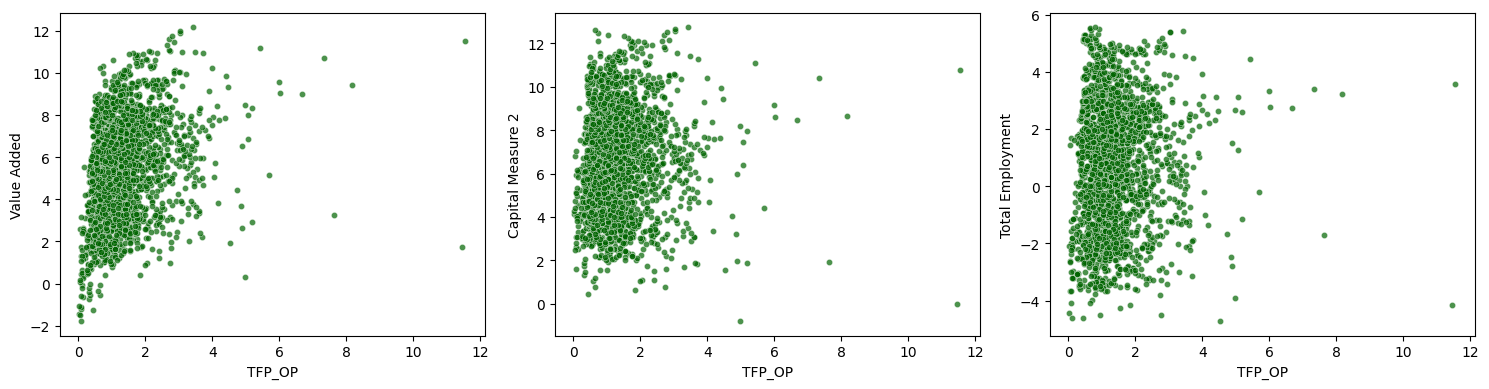

In [38]:
pair_plot_df = df_OP[['Value Added',
                      k,
                      l,
                      'TFP_OP']]

pair_plot_df = pair_plot_df.reset_index()
pair_plot_df.drop(columns={'index'}, inplace=True)

main_var = 'TFP_OP'
other_vars = [col for col in pair_plot_df.columns if col != main_var]

fig, axes = plt.subplots(1, len(other_vars), figsize=(5 * len(other_vars), 4))
if len(other_vars) == 1:
    axes = [axes]

for ax, var in zip(axes, other_vars):
    
    sns.scatterplot(x=pair_plot_df[main_var], y=pair_plot_df[var], alpha=0.7, s=20, color='darkgreen', ax=ax)
    ax.set_xlabel(main_var)
    ax.set_ylabel(var)

plt.tight_layout()
plt.show()

In [39]:
df_OP

,Ticker Symbol,time,year,Total Employment,Capital Measure 1,Capital Measure 2,Capital Expenditure,Revenue - Total,Cost of Goods Sold,Survival,Value Added,y_next,l_next,k_next,phi_hat,survival_prob,TFP_OP
0,A,12,2020.0,2.797281,9.143239,9.121509,7.083388,8.582794,7.727976,1,8.028781,8.201660,2.833213,9.222467,7.870711,0.945139,1.461165
1,A,13,2021.0,2.833213,9.263597,9.222467,7.161622,8.751316,7.890583,1,8.201660,8.285261,2.895912,9.222862,7.955979,0.943862,1.594563
2,A,14,2022.0,2.895912,9.290721,9.222862,5.755742,8.831712,7.966587,1,8.285261,8.216358,2.895912,9.327501,7.745842,0.857195,1.714632
3,A,15,2023.0,2.895912,9.358760,9.327501,6.731018,8.829519,8.049427,1,8.216358,8.235626,2.884801,9.429556,7.965959,0.925344,1.474051
4,A,16,2024.0,2.884801,9.425129,9.429556,6.776507,8.781095,7.914618,0,8.235626,NaN,NaN,NaN,8.037437,0.921111,1.389477
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2325,ZYXI,10,2018.0,-1.703749,2.427895,1.942189,2.228616,3.463139,1.720979,1,3.270595,3.622633,-1.262308,3.283877,1.441072,0.949022,7.643980
2326,ZYXI,11,2019.0,-1.262308,3.299608,3.283877,2.795328,3.817097,2.083931,1,3.622633,4.163202,-0.263966,4.280644,2.518986,0.941180,3.510178
2327,ZYXI,12,2020.0,-0.263966,4.301874,4.280644,3.853970,4.383550,2.762854,1,4.163202,4.656604,-0.256183,4.399854,3.465118,0.946651,2.321476
2328,ZYXI,13,2021.0,-0.256183,4.838755,4.399854,3.962887,4.869847,3.219795,1,4.656604,5.007624,0.095310,4.867150,3.562135,0.947205,3.457479


In [40]:
decomposition_df, OP_decomp = decomposition(df_OP, 'TFP_OP')

In [41]:
print(decomposition_df)

        unweighted_mean_p  weighted_mean_p  covariance_term
year                                                       
2010.0           0.189255         0.328148         0.138893
2011.0           0.186856         0.248312         0.061457
2012.0           0.124805         0.225371         0.100566
2013.0           0.168448         0.257269         0.088821
2014.0           0.188245         0.231889         0.043644
2015.0           0.050918         0.149902         0.098984
2016.0           0.165480         0.209060         0.043580
2017.0           0.147456         0.238330         0.090874
2018.0           0.181406         0.237177         0.055772
2019.0           0.163528         0.253557         0.090028
2020.0           0.080293         0.190899         0.110606
2021.0           0.020886         0.263537         0.242651
2022.0           0.131945         0.282691         0.150746
2023.0           0.112189         0.221509         0.109321
2024.0           0.088063         0.3033

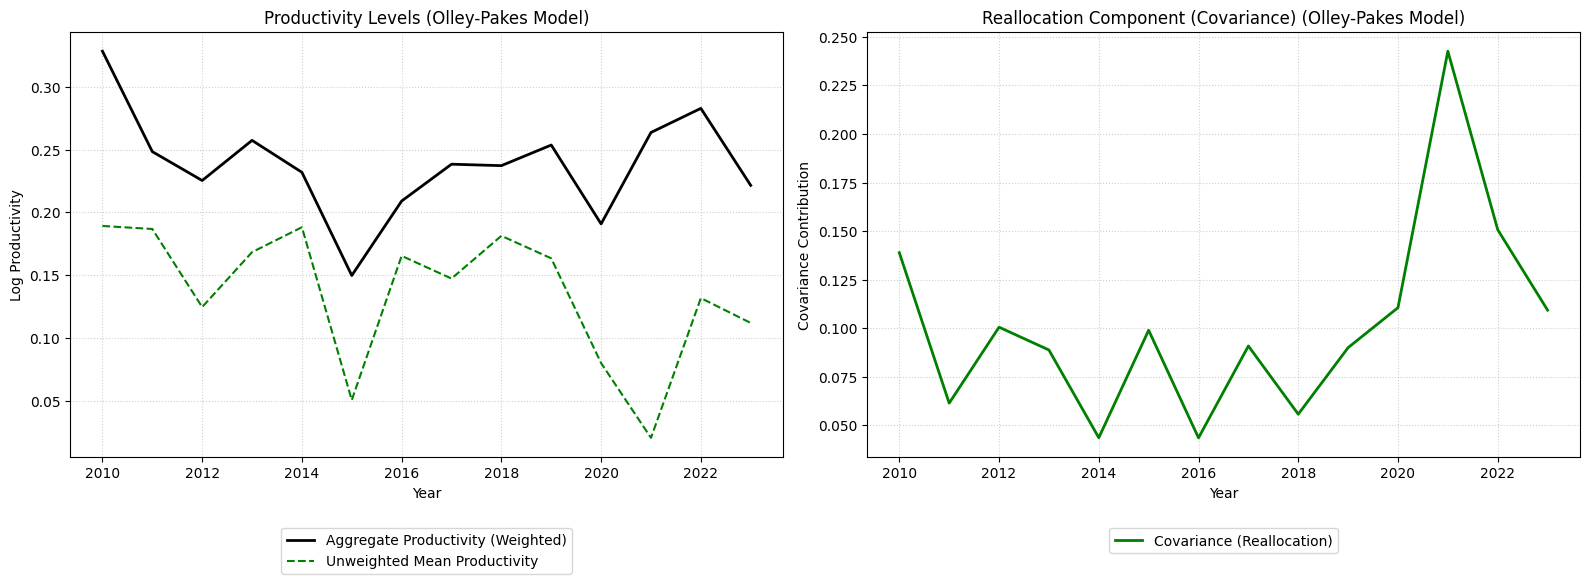

In [42]:
TFP_plot(decomposition_df, 'Olley-Pakes Model')

In [43]:
decomp_cols = ['year', 'time', 'Ticker Symbol', 'TFP_OP', 'Revenue - Total', 'cov_contribution']
OP_decomp[decomp_cols].to_csv(f'{parent_dir}/output/TFP/Annual/TFP_OP.csv')

In [44]:
params = k, l, beta_l, beta_k_final
OP_model.invertibility_test(df_OP, params)

--- Robustness Test Results (Section 4.1) ---
Original Beta_K: 0.7863
Robust Beta_K:   0.5843
Gamma_L (Coeff on Lagged Labor): -0.2881
FAIL: Gamma_L is large. Labor might be determining investment decisions.


In [45]:
stage1_params = ('Value Added', i, k, l)
stage2_params = ('Value Added', k, l)
k_iqr, l_iqr = OP_model.OP_bootstrap(df_OP, stage1_params, stage2_params, n_bootstraps=50, impute_labor=False)

Optimization terminated successfully.
         Current function value: 0.222672
         Iterations 7
Iter 1: k=0.774, l=0.151
Optimization terminated successfully.
         Current function value: 0.242936
         Iterations 6
Iter 2: k=0.726, l=0.227
Optimization terminated successfully.
         Current function value: 0.221854
         Iterations 7
Iter 3: k=0.785, l=0.256
Optimization terminated successfully.
         Current function value: 0.223085
         Iterations 7
Iter 4: k=0.884, l=0.132
Optimization terminated successfully.
         Current function value: 0.216632
         Iterations 6
Iter 5: k=0.803, l=0.161
Optimization terminated successfully.
         Current function value: 0.232853
         Iterations 6
Iter 6: k=0.693, l=0.224
Optimization terminated successfully.
         Current function value: 0.224734
         Iterations 7
Iter 7: k=0.770, l=0.191
Optimization terminated successfully.
         Current function value: 0.250804
         Iterations 8
Iter 8: k

## **Model 4: ACKERBERG-CAVES-FRAZER Model**

We estimate the following Leontief-derived value-added production function:

$$Y_{it} = \beta_0 K^{\beta_{k}}_{it} L^{\beta_{l}}_{it} e^{\omega_{it}} e^{\epsilon_{it}}$$

When we use the ACF procedure, we use $M_{it}$ to invert the productivity shock.

In [46]:
ACF_df = capital2[['Ticker Symbol',
                    'time',
                    'year',
                    'Revenue - Total',
                    'Total Employment',
                    'Capital Measure 2', 
                    'Inventories - Raw Materials',
                    'Cost of Goods Sold',
                    'Value Added']]

ACF_df = ACF_df.dropna().reset_index(drop=True)

In [47]:
k = 'Capital Measure 2'
m = 'Inventories - Raw Materials'
l = 'Total Employment'
y = 'Value Added'
t = 'time'

For our procedure, our first stage is simply OLS of yit on $k_{it}$, $l_{lt}$, and $m_{it}$. More generally, one would want higher order polynomials in the explanatory variables, but because, in our setup, optimal $m_{it}$ is actually a linear function of $k_{it}$ > $l_{it}$, and $\omega_{it}$ we simply use a first order polynomial.

In [48]:
params = (y, k, l, m, t)

ACF_stage1 = ACF_model.stage_1(ACF_df, params)
print(ACF_stage1.summary())

                            OLS Regression Results                            
Dep. Variable:            Value Added   R-squared:                       0.935
Model:                            OLS   Adj. R-squared:                  0.934
Method:                 Least Squares   F-statistic:                     997.9
Date:                Tue, 21 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:18:09   Log-Likelihood:                -2138.3
No. Observations:                2330   AIC:                             4345.
Df Residuals:                    2296   BIC:                             4540.
Df Model:                          33                                         
Covariance Type:            nonrobust                                         
                                                                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------

In the second stage, our estimation is based on the following moments (where $\tilde{\beta}_0$ = ln($\beta_0$)):

\begin{equation}
E \left[
\begin{aligned}
    & \left( y_{it} - \widetilde{\beta}_0 - \beta_k k_{it} - \beta_l l_{it} \right. \\
    & \quad \left. - \rho \cdot \left( \widetilde{\Phi}_{t-1}(k_{it-1}, l_{it-1}, m_{it-1}) - \widetilde{\beta}_0 - \beta_k k_{it-1} - \beta_l l_{it-1} \right) \right) \\
    & \otimes \begin{pmatrix}
        1 \\
        k_{it} \\
        l_{it-1} \\
        \widetilde{\Phi}_{t-1}(k_{it-1}, l_{it-1}, m_{it-1})
    \end{pmatrix}
\end{aligned}
\right] = 0.
\tag{40}
\end{equation}

In [49]:
ACF_df['phi_hat'] = ACF_stage1.fittedvalues

In [50]:
params = y, k, l
beta_k_est, beta_l_est, df_full, df_stage2 = ACF_model.stage_2(ACF_df, params, ACF_stage1)
print(f"Full sample: beta_k={beta_k_est:.4f}, beta_l={beta_l_est:.4f}")

x0=[0.2,0.4] -> k=0.6373, l=0.3096, obj=0.00056820
x0=[0.2,0.6] -> k=0.6373, l=0.3096, obj=0.00056820
x0=[0.2,0.8] -> k=0.5237, l=1.1521, obj=0.00001650
x0=[0.2,1.0] -> k=0.5237, l=1.1521, obj=0.00001650
x0=[0.2,1.2] -> k=0.5237, l=1.1521, obj=0.00001650
x0=[0.3,0.4] -> k=0.6373, l=0.3096, obj=0.00056820
x0=[0.3,0.6] -> k=0.6373, l=0.3096, obj=0.00056820
x0=[0.3,0.8] -> k=0.5237, l=1.1521, obj=0.00001650
x0=[0.3,1.0] -> k=0.5237, l=1.1521, obj=0.00001650
x0=[0.3,1.2] -> k=0.5237, l=1.1521, obj=0.00001650
x0=[0.4,0.4] -> k=0.6373, l=0.3096, obj=0.00056820
x0=[0.4,0.6] -> k=0.5237, l=1.1521, obj=0.00001650
x0=[0.4,0.8] -> k=0.5237, l=1.1521, obj=0.00001650
x0=[0.4,1.0] -> k=0.5237, l=1.1521, obj=0.00001650
x0=[0.4,1.2] -> k=0.5237, l=1.1521, obj=0.00001650
x0=[0.5,0.4] -> k=0.6373, l=0.3096, obj=0.00056820
x0=[0.5,0.6] -> k=0.5237, l=1.1521, obj=0.00001650
x0=[0.5,0.8] -> k=0.5237, l=1.1521, obj=0.00001650
x0=[0.5,1.0] -> k=0.5237, l=1.1521, obj=0.00001650
x0=[0.5,1.2] -> k=0.5237, l=1.1

In [51]:
ACF_df['ln_TFP'] = ACF_df['phi_hat'] - (beta_k_est * ACF_df[k]) - (beta_l_est * ACF_df[l])
ACF_df['ln_TFP'].describe()

count    2330.000000
mean        1.195863
std         1.491126
min        -3.768581
25%         0.116757
50%         1.202182
75%         2.341745
max         4.906204
Name: ln_TFP, dtype: float64

In [52]:
rho_params = k, l, beta_k_est, beta_l_est
ACF_model.calculate_rho(df_stage2, rho_params)

Estimated Rho: 0.9847


np.float64(0.9847478758081103)

In [53]:
boot_params = y, k, l, m
acf.bootstrap_se(ACF_df, boot_params, impute_labor=False, n_bootstraps=50)

Iter 1: k=0.590, l=0.569
Iter 2: k=0.246, l=1.559
Iter 3: k=0.595, l=0.881
Iter 4: k=0.426, l=1.356
Iter 5: k=0.433, l=0.754
Iter 6: k=0.460, l=1.782
Iter 7: k=0.539, l=0.878
Iter 8: k=0.560, l=0.736
Iter 9: k=0.401, l=1.530
Iter 10: k=0.303, l=2.328
Iter 11: k=0.072, l=2.103
Iter 12: k=0.254, l=1.455
Iter 13: k=0.419, l=1.345
Iter 14: k=0.132, l=2.120
Iter 15: k=0.618, l=1.065
Iter 16: k=0.623, l=1.214
Iter 17: k=0.320, l=1.863
Iter 18: k=0.560, l=1.231
Iter 19: k=0.083, l=1.692
Iter 20: k=0.039, l=1.941
Iter 21: k=0.333, l=1.366
Iter 22: k=0.478, l=1.035
Iter 23: k=0.479, l=1.161
Iter 24: k=0.287, l=1.024
Iter 25: k=0.516, l=1.125
Iter 26: k=0.417, l=1.144
Iter 27: k=0.404, l=1.662
Iter 28: k=0.335, l=1.862
Iter 29: k=0.399, l=1.204
Iter 30: k=0.491, l=1.024
Iter 31: k=0.511, l=1.387
Iter 32: k=0.446, l=1.603
Iter 33: k=0.404, l=1.431
Iter 34: k=0.071, l=2.166
Iter 35: k=0.402, l=1.009
Iter 36: k=-0.018, l=2.137
Iter 37: k=0.392, l=1.096
Iter 38: k=0.344, l=1.900
Iter 39: k=0.547, l=

(np.float64(0.14161756137205664), np.float64(0.4867890842517562))

In [54]:
ACF_df['TFP_ACF'] = np.exp(ACF_df['ln_TFP'])
ACF_agg, ACF_firm = decomposition(ACF_df, 'TFP_ACF')

In [55]:
decomp_cols = ['year', 'time', 'Ticker Symbol', 'ln_TFP', 'Revenue - Total', 'cov_contribution']
ACF_firm[decomp_cols].to_csv(f'{parent_dir}/output/TFP/Annual/TFP_ACF.csv')

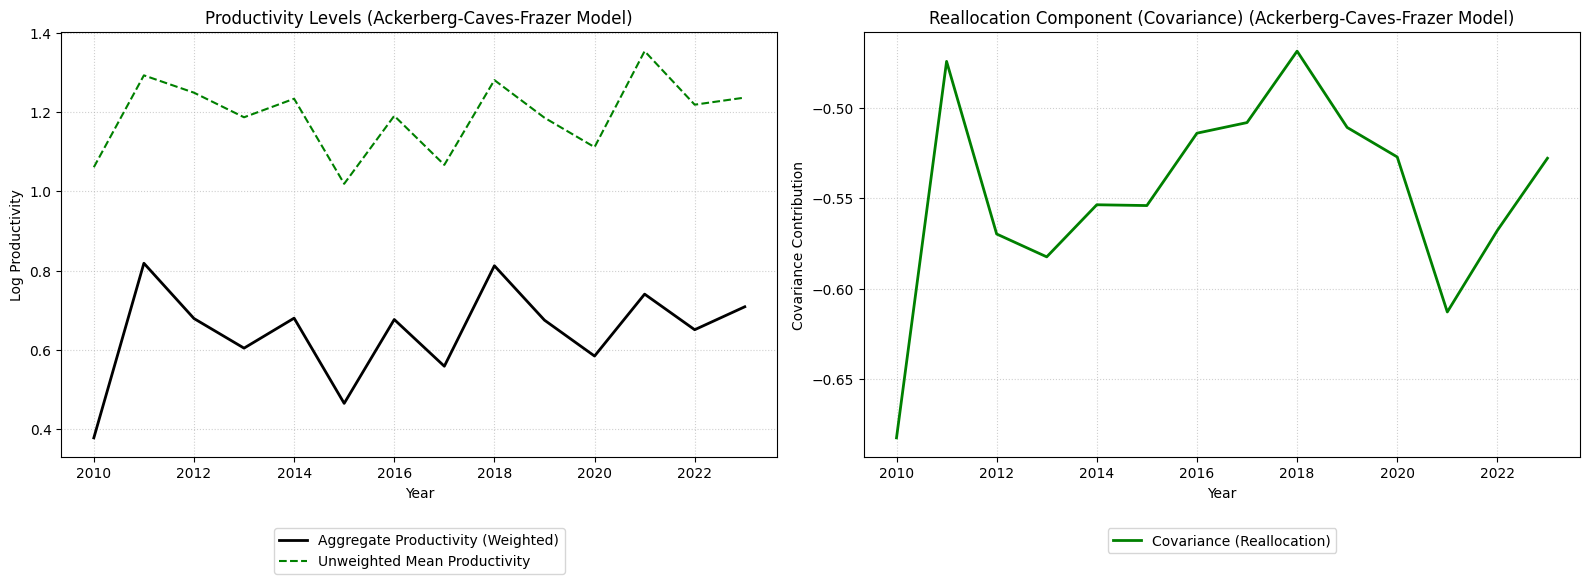

In [56]:
TFP_plot(ACF_agg, 'Ackerberg-Caves-Frazer Model')

### **ACKERBERG-CAVES-FRAZER Model Split by Year**

#### ***For Years Prior to 2017***

In [57]:
y, k, l, m, t = 'Value Added', 'Total Employment', 'Capital Measure 2', 'Inventories - Raw Materials', 'time'

ACF_COLUMNS = ['Ticker Symbol', 'time', 'year',
                'Revenue - Total', 'Total Employment',
                'Capital Measure 2', 'Inventories - Raw Materials',
                'Cost of Goods Sold', 'Value Added']

# Pre-2017 cohort
ACF_df_y1 = acf.prepare_acf_df(capital2, ACF_COLUMNS, year_cutoff=2017, before=True)

In [58]:
stage1_params = (y, k, l, m, t)
stage2_params = (y, k, l)
boot_params   = (y, k, l, m)

In [59]:
stage1_model_y1, ACF_df_y1 = acf.run_stage1(ACF_df_y1, stage1_params)

                            OLS Regression Results                            
Dep. Variable:            Value Added   R-squared:                       0.950
Model:                            OLS   Adj. R-squared:                  0.949
Method:                 Least Squares   F-statistic:                     668.9
Date:                Tue, 21 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:18:11   Log-Likelihood:                -685.97
No. Observations:                 901   AIC:                             1424.
Df Residuals:                     875   BIC:                             1549.
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                                                                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------

In [60]:
print(ACF_df_y1['time'].dtype)
print(ACF_df_y1['time'].nunique())
print(ACF_df_y1['time'].describe())

int64
7
count    901.000000
mean       5.322974
std        1.823615
min        2.000000
25%        4.000000
50%        5.000000
75%        7.000000
max        8.000000
Name: time, dtype: float64


In [61]:
beta_k_y1, beta_l_y1, df_full_y1, df_stage2_y1 = acf.run_stage2(ACF_df_y1, stage2_params, stage1_model_y1)

x0=[0.2,0.4] -> k=0.7303, l=-0.2378, obj=0.00001298
x0=[0.2,0.6] -> k=0.7303, l=-0.2378, obj=0.00001298
x0=[0.2,0.8] -> k=-0.0939, l=1.0864, obj=0.00000070
x0=[0.2,1.0] -> k=-0.0939, l=1.0864, obj=0.00000070
x0=[0.2,1.2] -> k=-0.0939, l=1.0864, obj=0.00000070
x0=[0.3,0.4] -> k=0.7303, l=-0.2378, obj=0.00001298
x0=[0.3,0.6] -> k=0.7303, l=-0.2378, obj=0.00001298
x0=[0.3,0.8] -> k=-0.0939, l=1.0864, obj=0.00000070
x0=[0.3,1.0] -> k=-0.0939, l=1.0864, obj=0.00000070
x0=[0.3,1.2] -> k=-0.0939, l=1.0864, obj=0.00000070
x0=[0.4,0.4] -> k=0.7303, l=-0.2378, obj=0.00001298
x0=[0.4,0.6] -> k=-0.0939, l=1.0864, obj=0.00000070
x0=[0.4,0.8] -> k=-0.0939, l=1.0864, obj=0.00000070
x0=[0.4,1.0] -> k=-0.0939, l=1.0864, obj=0.00000070
x0=[0.4,1.2] -> k=-0.0939, l=1.0864, obj=0.00000070
x0=[0.5,0.4] -> k=0.7303, l=-0.2378, obj=0.00001298
x0=[0.5,0.6] -> k=-0.0939, l=1.0864, obj=0.00000070
x0=[0.5,0.8] -> k=-0.0939, l=1.0864, obj=0.00000070
x0=[0.5,1.0] -> k=-0.0939, l=1.0864, obj=0.00000070
x0=[0.5,1.2]

In [62]:
ACF_df_y1 = acf.compute_ln_tfp(ACF_df_y1, k, l, beta_k_y1, beta_l_y1)

count    901.000000
mean      -1.618116
std        0.271101
min       -2.932363
25%       -1.720096
50%       -1.602035
75%       -1.489888
max        1.070317
Name: ln_TFP, dtype: float64


In [63]:
acf.compute_rho(df_stage2_y1, k, l, beta_k_y1, beta_l_y1)

Estimated Rho: 0.9282


np.float64(0.9281670640053485)

In [64]:
acf.bootstrap_se(ACF_df_y1, boot_params, impute_labor = False, n_bootstraps=50)

Iter 1: k=0.323, l=0.819
Iter 2: k=-0.078, l=1.112
Iter 3: k=-0.411, l=1.294
Iter 4: k=0.479, l=0.538
Iter 5: k=-0.213, l=1.203
Iter 6: k=-0.128, l=1.127
Iter 7: k=-0.213, l=1.204
Iter 8: k=0.417, l=1.432
Iter 9: k=-0.044, l=1.083
Iter 10: k=0.585, l=0.583
Iter 11: k=0.190, l=0.798
Iter 12: k=0.630, l=0.752
Iter 13: k=0.178, l=0.912
Iter 14: k=0.489, l=0.899
Iter 15: k=-3.041, l=8.270
Iter 16: k=-0.054, l=1.097
Iter 17: k=-0.066, l=1.886
Iter 18: k=-0.213, l=1.322
Iter 19: k=0.825, l=0.740
Iter 20: k=0.206, l=0.837
Iter 21: k=0.962, l=-0.811
Iter 22: k=0.443, l=0.701
Iter 23: k=-0.053, l=1.062
Iter 24: k=-0.297, l=1.251
Iter 25: k=-0.508, l=1.566
Iter 26: k=0.056, l=0.998
Iter 27: k=-0.265, l=1.254
Iter 28: k=-0.053, l=1.173
Iter 29: k=-0.283, l=1.743
Iter 30: k=-0.050, l=1.100
Iter 31: k=-0.153, l=1.195
Iter 32: k=-0.312, l=1.549
Iter 33: k=1.348, l=-1.132
Iter 34: k=-0.098, l=1.080
Iter 35: k=-0.163, l=1.133
Iter 36: k=1.199, l=0.242
Iter 37: k=-0.143, l=1.110
Iter 38: k=0.271, l=0.8

(np.float64(0.3782049024503678), np.float64(0.31079032595939304))

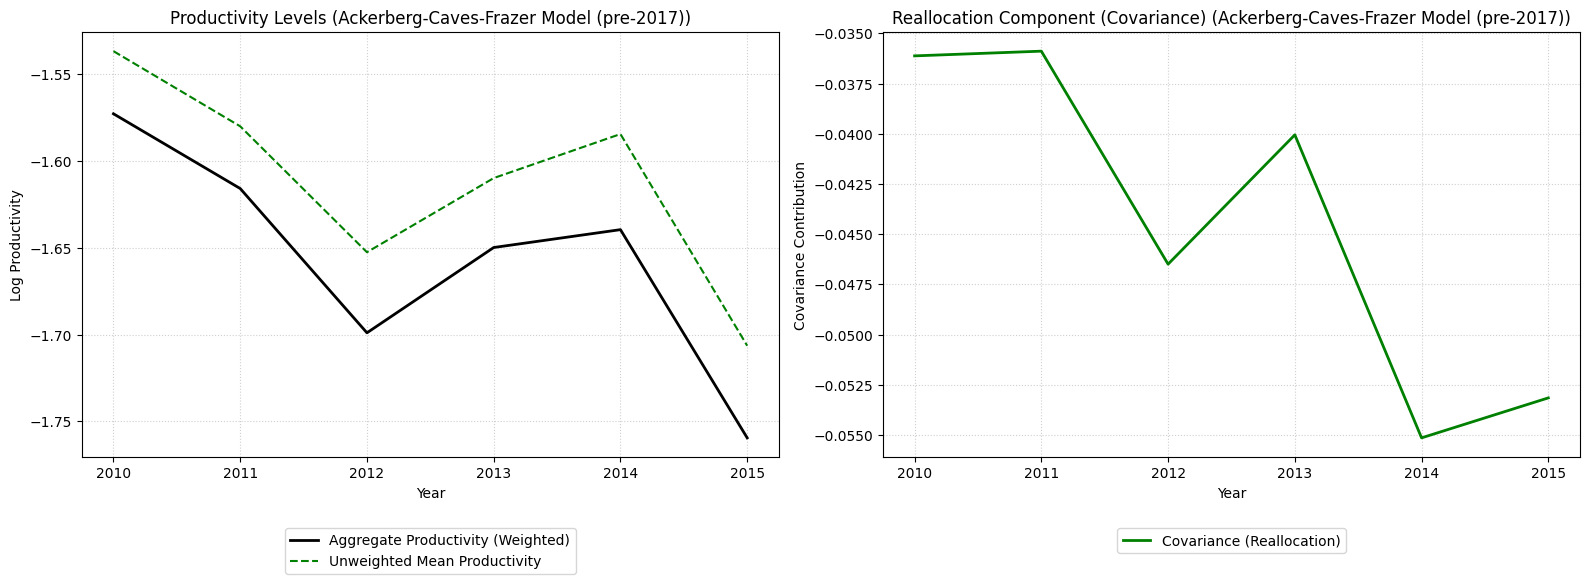

In [65]:
DECOMP_COLS = ['year', 'time', 'Ticker Symbol',
               'ln_TFP', 'Revenue - Total', 'cov_contribution']

agg_y1, firm_y1 = acf.decompose_and_plot(
    ACF_df_y1, DECOMP_COLS,
    label='Ackerberg-Caves-Frazer Model (pre-2017)',
    output_path=acf.PARENT_DIR / 'output' / 'TFP' / 'Annual' / 'TFP_ACF_y1.csv',
)

#### ***For Years After 2017***

In [66]:
y, k, l, m, t = 'Value Added', 'Total Employment', 'Capital Measure 2', 'Inventories - Raw Materials', 'time'

# Post-2017 cohort
ACF_df_y2 = acf.prepare_acf_df(capital2, ACF_COLUMNS, year_cutoff=2017, before=False)

In [67]:
stage1_params = (y, k, l, m, t)
stage2_params = (y, k, l)
boot_params   = (y, k, l, m)

In [68]:
stage1_model_y2, ACF_df_y2 = acf.run_stage1(ACF_df_y2, stage1_params)

                            OLS Regression Results                            
Dep. Variable:            Value Added   R-squared:                       0.928
Model:                            OLS   Adj. R-squared:                  0.927
Method:                 Least Squares   F-statistic:                     697.2
Date:                Tue, 21 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:18:12   Log-Likelihood:                -1397.5
No. Observations:                1429   AIC:                             2849.
Df Residuals:                    1402   BIC:                             2991.
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                                                                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------

In [69]:
print(ACF_df_y2['time'].dtype)
print(ACF_df_y2['time'].nunique())
print(ACF_df_y2['time'].describe())

int64
8
count    1429.000000
mean       12.380686
std         2.135289
min         9.000000
25%        11.000000
50%        12.000000
75%        14.000000
max        16.000000
Name: time, dtype: float64


In [70]:
beta_k_y2, beta_l_y2, df_full_y2, df_stage2_y2 = acf.run_stage2(ACF_df_y2, stage2_params, stage1_model_y2)

x0=[0.2,0.4] -> k=0.1706, l=0.8463, obj=0.00002237
x0=[0.2,0.6] -> k=0.1706, l=0.8463, obj=0.00002237
x0=[0.2,0.8] -> k=0.1706, l=0.8463, obj=0.00002237
x0=[0.2,1.0] -> k=0.8957, l=0.4082, obj=0.00006520
x0=[0.2,1.2] -> k=0.8957, l=0.4082, obj=0.00006520
x0=[0.3,0.4] -> k=0.1706, l=0.8463, obj=0.00002237
x0=[0.3,0.6] -> k=0.1706, l=0.8463, obj=0.00002237
x0=[0.3,0.8] -> k=0.1706, l=0.8463, obj=0.00002237
x0=[0.3,1.0] -> k=0.8957, l=0.4082, obj=0.00006520
x0=[0.3,1.2] -> k=0.8957, l=0.4082, obj=0.00006520
x0=[0.4,0.4] -> k=0.1706, l=0.8463, obj=0.00002237
x0=[0.4,0.6] -> k=0.1706, l=0.8463, obj=0.00002237
x0=[0.4,0.8] -> k=0.8957, l=0.4082, obj=0.00006520
x0=[0.4,1.0] -> k=0.8957, l=0.4082, obj=0.00006520
x0=[0.4,1.2] -> k=0.8957, l=0.4082, obj=0.00006520
x0=[0.5,0.4] -> k=0.1706, l=0.8463, obj=0.00002237
x0=[0.5,0.6] -> k=0.8957, l=0.4082, obj=0.00006520
x0=[0.5,0.8] -> k=0.8957, l=0.4082, obj=0.00006520
x0=[0.5,1.0] -> k=0.8957, l=0.4082, obj=0.00006520
x0=[0.5,1.2] -> k=0.8957, l=0.4

In [71]:
acf.compute_rho(df_stage2_y2, k, l, beta_k_y2, beta_l_y2)

Estimated Rho: 0.9107


np.float64(0.9106650234938215)

In [72]:
acf.bootstrap_se(ACF_df_y2, boot_params, impute_labor=False, n_bootstraps=50)

Iter 1: k=-0.416, l=2.400
Iter 2: k=0.559, l=0.898
Iter 3: k=0.123, l=0.910
Iter 4: k=0.348, l=1.417
Iter 5: k=0.262, l=0.191
Iter 6: k=0.118, l=1.246
Iter 7: k=0.117, l=0.884
Iter 8: k=0.434, l=1.169
Iter 9: k=0.413, l=1.050
Iter 10: k=0.082, l=0.966
Iter 11: k=0.236, l=0.871
Iter 12: k=1.027, l=0.269
Iter 13: k=0.752, l=0.469
Iter 14: k=-0.192, l=1.269
Iter 15: k=0.956, l=0.393
Iter 16: k=1.036, l=0.441
Iter 17: k=0.238, l=0.901
Iter 18: k=0.875, l=0.360
Iter 19: k=0.029, l=0.989
Iter 20: k=0.124, l=1.003
Iter 21: k=0.829, l=0.818
Iter 22: k=0.352, l=-0.004
Iter 23: k=0.851, l=0.911
Iter 24: k=0.138, l=1.481
Iter 25: k=0.888, l=0.396
Iter 26: k=0.667, l=0.689
Iter 27: k=0.259, l=1.469
Iter 28: k=0.202, l=2.074
Iter 29: k=0.419, l=1.020
Iter 30: k=0.130, l=1.022
Iter 31: k=0.100, l=1.053
Iter 32: k=0.213, l=0.224
Iter 33: k=0.837, l=0.591
Iter 34: k=0.717, l=0.566
Iter 35: k=-0.007, l=0.758
Iter 36: k=0.329, l=0.554
Iter 37: k=0.307, l=1.995
Iter 38: k=0.810, l=0.242
Iter 39: k=-0.171

(np.float64(0.45355417450156865), np.float64(0.367826559137024))

count    1429.000000
mean       -0.292341
std         0.267608
min        -3.073915
25%        -0.349789
50%        -0.249067
75%        -0.185461
max         0.767725
Name: ln_TFP, dtype: float64


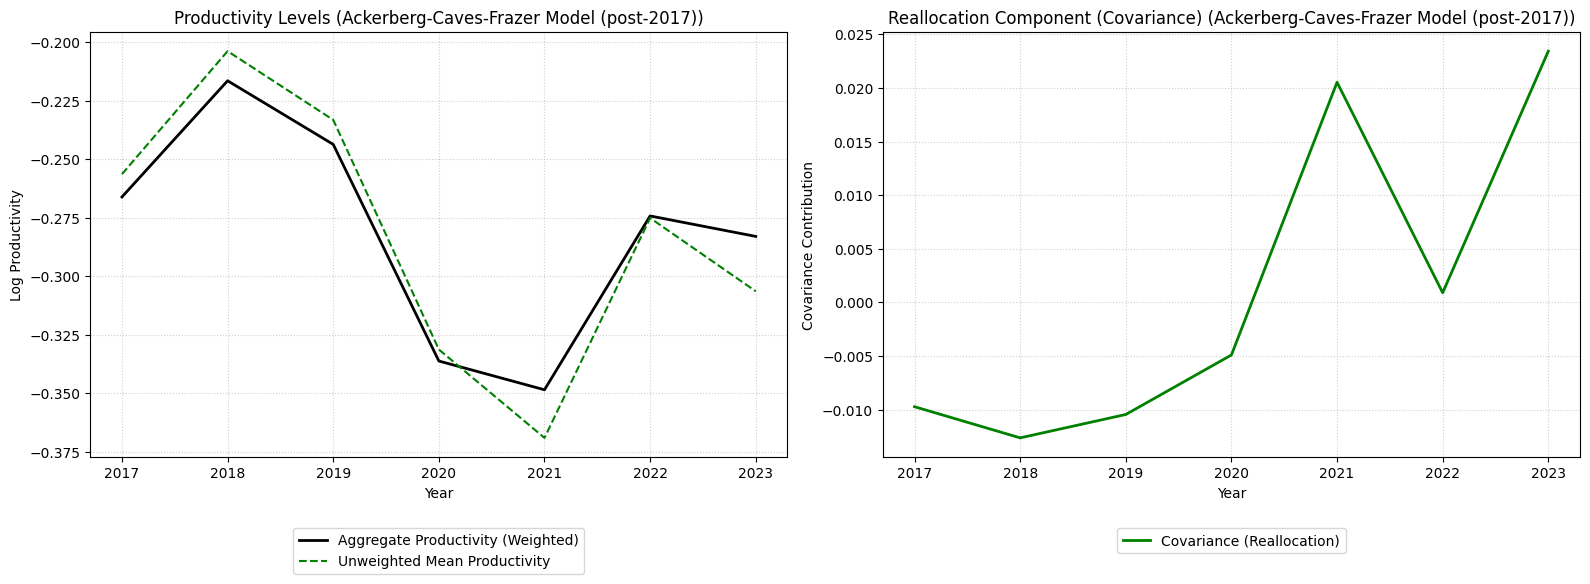

In [73]:
ACF_df_y2 = acf.compute_ln_tfp(ACF_df_y2, k, l, beta_k_y2, beta_l_y2)

agg_y2, firm_y2 = acf.decompose_and_plot(
    ACF_df_y2, DECOMP_COLS,
    label='Ackerberg-Caves-Frazer Model (post-2017)',
    output_path=acf.PARENT_DIR / 'output' / 'TFP' / 'Annual' / 'TFP_ACF_y2.csv')